# 04 — Error analysis

Dónde el modelo gana, dónde pierde. Lectura por segmento (formato, región, categoría) y por evento (Buen Fin, quincena, fin de semana).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from retail_ops_forecasting.config import load_config
from retail_ops_forecasting.data import load_transactions, load_stores, load_calendar, build_merged
sns.set_style('whitegrid')
cfg = load_config(ROOT / 'configs' / 'config.yaml')


## Cargar predicciones de test

In [2]:
from retail_ops_forecasting.data import load_stores, load_calendar
demand_test = pd.read_csv(ROOT / 'data' / 'processed' / 'demand_predictions_test.csv', parse_dates=['date'])
cash_test = pd.read_csv(ROOT / 'data' / 'processed' / 'cash_predictions_test.csv', parse_dates=['date'])
stores = load_stores(cfg.paths.raw_dir / cfg.data.stores_file)
cal = load_calendar(cfg.paths.raw_dir / cfg.data.calendar_file)
demand_test.head(2)

,store_id,category,date,total_transactions,y_pred
0,STR_001,Abarrotes,2023-12-01,3708,2483.178292
1,STR_001,Abarrotes,2023-12-02,5834,3263.494447


## Residuos por categoría

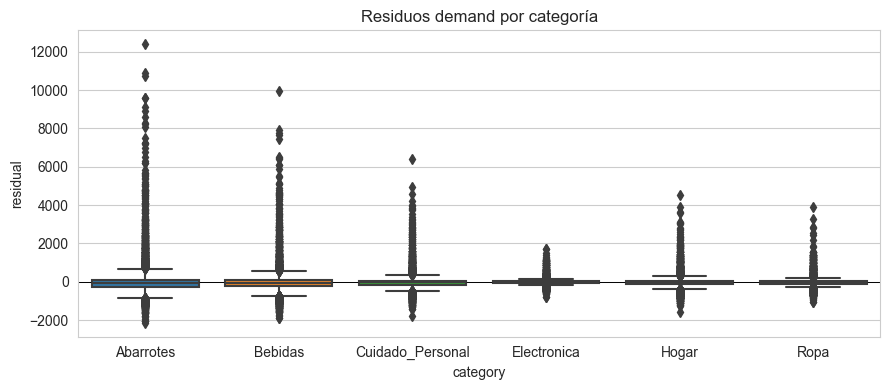

In [3]:
d = demand_test.rename(columns={cfg.targets.demand_primary:'y_true'}).merge(stores, on='store_id', how='left')
d['residual'] = d['y_true'] - d['y_pred']
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=d, x='category', y='residual', ax=ax)
ax.axhline(0, color='k', lw=0.7); ax.set_title('Residuos demand por categoría')
plt.tight_layout(); plt.savefig(ROOT / 'reports' / 'figures' / 'error_demand_by_category.png', dpi=120); plt.show()

## WAPE por evento

In [4]:
from retail_ops_forecasting.metrics import wape
d = d.merge(cal[['date','is_buen_fin','is_navidad_season','is_payday','is_weekend','is_holiday','is_semana_santa']], on='date', how='left')
d['event'] = 'regular'
for col, lab in [('is_buen_fin','buen_fin'),('is_semana_santa','semana_santa'),('is_navidad_season','navidad'),('is_payday','payday'),('is_holiday','holiday'),('is_weekend','weekend')]:
    d.loc[d[col].fillna(False).astype(bool), 'event'] = lab
rows = [{'event': e, 'wape': wape(g['y_true'], g['y_pred']), 'n': len(g)} for e, g in d.groupby('event')]
pd.DataFrame(rows).round(4)

,event,wape,n
0,holiday,0.6489,1920
1,navidad,0.2893,6240
2,payday,0.2019,2400
3,regular,0.2461,20628
4,weekend,0.3140,12474


## Cash — coverage por tienda (P90)

coverage por tienda — min 0.86, median 0.96, max 0.99


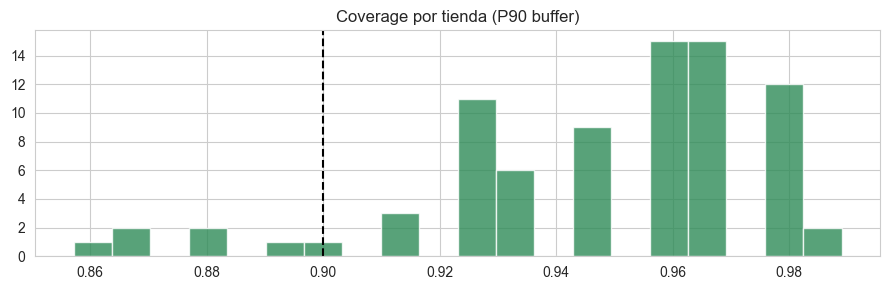

In [5]:
recs = pd.read_csv(ROOT / 'reports' / 'cash_forecast_recommendations.csv', parse_dates=['date'])
tcol = cfg.targets.cash_primary
recs['ok'] = recs['recommended_cash'] >= recs[tcol]
cov = recs.groupby('store_id')['ok'].mean().sort_values()
print(f'coverage por tienda — min {cov.min():.2f}, median {cov.median():.2f}, max {cov.max():.2f}')
fig, ax = plt.subplots(figsize=(9,3))
ax.hist(cov, bins=20, color='seagreen', alpha=0.8); ax.axvline(0.9, color='k', linestyle='--')
ax.set_title('Coverage por tienda (P90 buffer)')
plt.tight_layout(); plt.savefig(ROOT / 'reports' / 'figures' / 'cash_coverage_per_store.png', dpi=120); plt.show()